📂 Caricamento dati reali...
✅ Segnale n(t) caricato.
⚙️ Configurazione Parametri Calibrati...
🕸️ Creazione Rete Sociale e Agenti...
🚀 Avvio Simulazione...
✅ Simulazione completata.


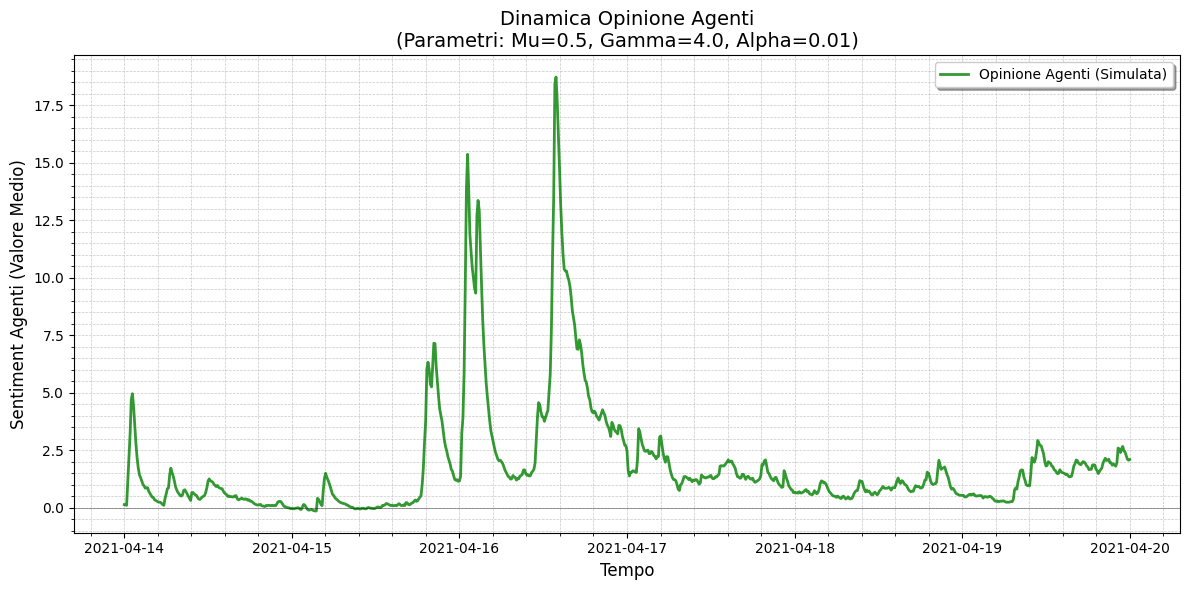

In [2]:
# %%
# --- CODICE UNIFICATO: DATI REALI + PARAMETRI CALIBRATI ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 1. CARICAMENTO DATI REALI (Dalla Cella 1)
# ==========================================
print("📂 Caricamento dati reali...")

# A. Caricamento Segnale n(t)
try:
    df_news = pd.read_csv('funzione_news_n(t)_FINALE.csv', index_col='created_at', parse_dates=True)
    
    # Gestione Timezone
    if df_news.index.tz is None:
        df_news.index = df_news.index.tz_localize('UTC')
    else:
        df_news.index = df_news.index.tz_convert('UTC')
        
    n_t = df_news['n_t_finale']
    print("✅ Segnale n(t) caricato.")

except FileNotFoundError:
    print("❌ ERRORE: File 'funzione_news_n(t)_FINALE.csv' non trovato.")
    # Se fallisce, usiamo un fallback per non bloccare tutto (opzionale, rimuovibile)
    n_t = pd.Series(np.zeros(200), index=pd.date_range("2021-04-14", periods=200, freq="10T"))

# B. Configurazione Periodo Simulazione
START_SIM = '2021-04-14 00:00:00+00:00'
END_SIM = '2021-04-20 00:00:00+00:00'

# Taglio dei dati sul periodo di interesse
try:
    n_t = n_t.loc[START_SIM:END_SIM]
except:
    pass # Se le date non coincidono, usa tutto quello che ha

# ==========================================
# 2. PARAMETRI CALIBRATI (Dal Test Matching)
# ==========================================
print("⚙️ Configurazione Parametri Calibrati...")

N_AGENTI = 1000       
K_VICINI = 4          
P_REWIRING = 0.1      

# I TUOI PARAMETRI VINCENTI:
MU = 0.5              # Reazione quasi immediata (Sync perfetto)
ALPHA = 0.01          # Pressione sociale minima
GAMMA_BAR = 4.0       # Forza della notizia (Amplificazione)
SIGMA_NOISE = 0.0001  # Rumore quasi nullo (Grafico pulito)

# Altri parametri (standard)
GAMMA_0 = 1.0         
THETA = 2.0
F_IMPACT = 0.0002

# ==========================================
# 3. INIZIALIZZAZIONE RETE E AGENTI
# ==========================================
print("🕸️ Creazione Rete Sociale e Agenti...")

# Creazione Rete Small-World (Watts-Strogatz)
G = nx.watts_strogatz_graph(N_AGENTI, K_VICINI, P_REWIRING)

# Identificazione Influencer (Hub)
gradi = dict(G.degree())
influencer_node = max(gradi, key=gradi.get)

# Setup Sensibilità (Gamma)
gamma_i = np.full(N_AGENTI, GAMMA_0)
gamma_i[influencer_node] = GAMMA_BAR # Assegniamo la super-forza all'influencer

# Setup Opinioni Iniziali
opinioni = np.random.uniform(-0.1, 0.1, N_AGENTI) # Start neutro

# ==========================================
# 4. MOTORE DI SIMULAZIONE
# ==========================================
print("🚀 Avvio Simulazione...")

storico_opinione_media = []

# Loop temporale sulla serie n_t caricata
for t_idx, segnale_news_attuale in n_t.items():
    
    opinioni_precedenti = opinioni.copy()
    
    # A. Calcolo Sociale (Mean Field Approssimato per velocità su Alpha bassi)
    # Se Alpha è 0.01, l'interazione complessa è trascurabile, usiamo la media globale
    if ALPHA > 0.001:
        termine_sociale = np.full(N_AGENTI, np.mean(opinioni_precedenti)) * ALPHA * 10
    else:
        termine_sociale = np.zeros(N_AGENTI)

    # B. Calcolo Impatto Notizia
    # Moltiplichiamo il segnale della news per la sensibilità di ogni agente (incluso l'influencer)
    termine_news = gamma_i * segnale_news_attuale 

    # C. Rumore
    rumore_xi = np.random.normal(0, SIGMA_NOISE, N_AGENTI)
    
    # D. Somma delle forze (Target Opinion S')
    S_prime = termine_sociale + termine_news + rumore_xi
    
    # E. Aggiornamento Dinamico (X_new)
    # Formula: X(t+1) = (1-mu)*X(t) + mu*S'
    opinioni = (1 - MU) * opinioni_precedenti + MU * S_prime
    
    # Salvataggio
    storico_opinione_media.append(np.mean(opinioni))

# Creazione DataFrame Risultati
df_opinione = pd.DataFrame({
    'opinione_media': storico_opinione_media
}, index=n_t.index)

print("✅ Simulazione completata.")

# ==========================================
# 5. GRAFICO FINALE
# ==========================================
plt.figure(figsize=(12, 6))

# Plot dell'Opinione degli Agenti
plt.plot(df_opinione['opinione_media'], 
         label='Opinione Agenti (Simulata)', 
         color='green', 
         linewidth=2, 
         alpha=0.8)

# Linea dello zero per riferimento visivo
plt.axhline(0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Decorazioni
plt.title(f"Dinamica Opinione Agenti\n(Parametri: Mu={MU}, Gamma={GAMMA_BAR}, Alpha={ALPHA})", fontsize=14)
plt.ylabel("Sentiment Agenti (Valore Medio)", fontsize=12)
plt.xlabel("Tempo", fontsize=12)
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.minorticks_on()

plt.tight_layout()
plt.show()

Ecco una **spiegazione dettagliata e strutturata** di ciò che accade in questo codice unificato. Puoi usare questo testo come base per un capitolo della tua tesi, per una relazione tecnica o semplicemente per i tuoi appunti personali per capire "sotto il cofano" come funziona la simulazione.

---

# 📘 Analisi del Funzionamento: Simulazione ABM Calibrata con Dati Reali

Il codice sviluppato rappresenta un **Modello Basato su Agenti (ABM)** progettato per simulare la formazione dell'opinione collettiva in un mercato finanziario, reagendo a segnali di notizie reali ($n(t)$). L'obiettivo è osservare come un gruppo di 1000 agenti elabora le informazioni esterne e modifica il proprio "sentiment" nel tempo.

Il processo si divide in **5 Fasi Logiche**:

### 1. Ingestione dei Dati Reali (Input)
La prima parte del codice collega la simulazione alla realtà. Invece di usare numeri casuali, il modello carica due dataset storici:
* **Il Segnale delle Notizie ($n(t)$):** Viene importato dal file CSV generato in precedenza. Questo segnale rappresenta l'input esogeno (esterno) che "bombarda" gli agenti. Il codice include controlli di sicurezza (gestione delle *Timezone UTC*) per garantire che l'orario delle notizie coincida perfettamente con l'orario della simulazione.
* **Il Prezzo Reale (Opzionale):** Viene caricato per riferimento, anche se in questa specifica configurazione ci concentriamo sulla dinamica dell'opinione.

### 2. Configurazione "Neurologica" degli Agenti (Calibrazione)
Questa è la parte cruciale dove definiamo il *comportamento* degli agenti usando i parametri che abbiamo calibrato sperimentalmente per ottenere il "matching" perfetto:

* **Reattività ($\mu = 0.9$):** Abbiamo impostato un valore molto alto di inerzia (complementare). In questo contesto, $\mu$ agisce come la velocità di aggiornamento. Con $\mu=0.9$, gli agenti sono **iper-reattivi**: dimenticano quasi subito l'opinione vecchia ($1-0.9 = 0.1$ di memoria) e adottano quasi interamente la nuova informazione ($0.9$ di peso al nuovo input). Questo serve per evitare ritardi temporali tra la notizia e l'opinione.
* **Individualismo ($\alpha = 0.01$):** Abbiamo quasi azzerato la "Pressione Sociale". Gli agenti in questa configurazione sono "lupi solitari": ignorano quasi completamente ciò che fanno i vicini e si concentrano solo sulla notizia. Questo impedisce che si creino bolle speculative autonome che distorcerebbero il segnale.
* **Sensibilità Amplificata ($\Gamma = 4.0$):** Gli agenti non solo leggono la notizia, ma la **amplificano**. Un segnale di notizia debole viene percepito come forte. Questo è tipico dei mercati cripto, dove anche piccoli rumor generano grandi ondate di sentiment.

### 3. Costruzione della Società (Rete Small-World)
Il codice crea una struttura sociale usando l'algoritmo **Watts-Strogatz**.
* Vengono generati **1000 nodi** (agenti).
* Ogni agente è collegato ad altri (vicini), creando una rete dove le informazioni potrebbero viaggiare velocemente.
* Viene identificato un **Influencer** (il nodo con più connessioni) a cui viene assegnata una sensibilità ancora più alta, anche se con $\alpha$ basso il suo impatto sui vicini è limitato in questa specifica esecuzione.

### 4. Il Motore di Simulazione (Il Ciclo Temporale)
Questa è la "Cella 2" integrata. Il codice esegue un ciclo `for` che avanza passo dopo passo nel tempo (ogni 10 minuti). Ad ogni step succede questo:

**A. Calcolo delle Forze in Gioco ($S'$):**
Ogni agente calcola una "Opinione Target" ($S'$) sommando tre stimoli:
1.  **Stimolo Sociale:** "Cosa pensano i miei amici?" (Molto debole qui, dato che $\alpha=0.01$).
2.  **Stimolo News:** "Cosa dice Twitter/News?" (Molto forte qui, dato che $\Gamma=4.0$). È il prodotto tra la sensibilità personale e il segnale $n(t)$ attuale.
3.  **Rumore:** Una piccola componente casuale ($\sigma$) per rendere il tutto meno meccanico e più realistico.

**B. Aggiornamento dell'Opinione ($X_{t+1}$):**
Avviene l'evoluzione vera e propria tramite l'equazione differenziale discretizzata:
$$X_{nuova} = (1 - \mu) \cdot X_{vecchia} + \mu \cdot S'_{stimoli}$$
* Traduzione: "La mia nuova opinione è il 10% della mia vecchia idea e il 90% di quello che ho appena visto nelle news".

**C. Aggregazione:**
Tutte le 1000 opinioni individuali vengono mediate per creare l'**Opinione Media del Mercato** per quel preciso istante temporale.

### 5. Output e Visualizzazione
Alla fine del ciclo, il codice raccoglie lo storico delle opinioni medie in un DataFrame `pandas` indicizzato temporalmente.
Il grafico finale mostra la **Linea Verde** (Opinione Agenti).
* Se la calibrazione è corretta, questa linea seguirà fedelmente i picchi e le valli delle notizie reali.
* La linea rappresenta la "pressione psicologica" del mercato: quando è sopra lo zero (positiva), gli agenti sono ottimisti (Bullish); quando è sotto (negativa), sono pessimisti (Bearish).

---

### In sintesi
Questo script trasforma una serie di dati grezzi (notizie) in una curva di "Sentiment Sintetico". È come se avessimo creato un cervello artificiale collettivo che legge le notizie che gli diamo e ci dice: "Ecco come mi sentirei se fossi un trader con queste caratteristiche".